In [ ]:
pip install scikit-learn pandas numpy matplotlib seaborn nltk joblib streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All libraries imported!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMRUTHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AMRUTHA\AppData\Roaming\nltk_data...


All libraries imported!


In [ ]:
df = pd.read_csv('emails.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel counts:")
print(df['spam'].value_counts())
df.head()

Shape: (5728, 2)
Columns: ['text', 'spam']

Label counts:
spam
0    4360
1    1368
Name: count, dtype: int64


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing emails...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Done!")
print("\nOriginal:", df['text'].iloc[0][:150])
print("\nCleaned :", df['clean_text'].iloc[0][:150])

Preprocessing emails...
Done!

Original: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the informa

Cleaned : subject naturally irresistible corporate identity really hard recollect company market full suqgestions information isoverwhelminq good catchy logo st


In [ ]:
X = df['clean_text']
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 4582
Testing samples  : 1146


In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)

Train shape: (4582, 10000)
Test shape : (1146, 10000)


In [ ]:
model = MultinomialNB(alpha=0.1)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

=== Classification Report ===
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       872
        Spam       0.98      0.96      0.97       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146



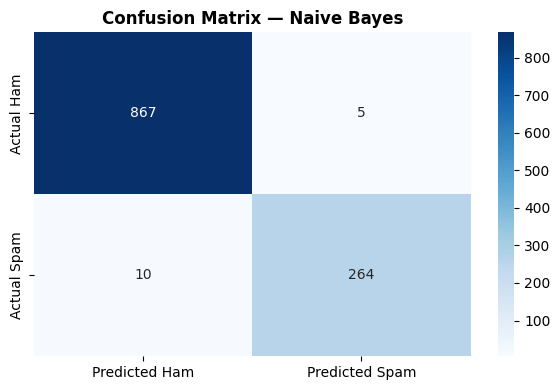

Saved: nb_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix — Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: nb_confusion_matrix.png")

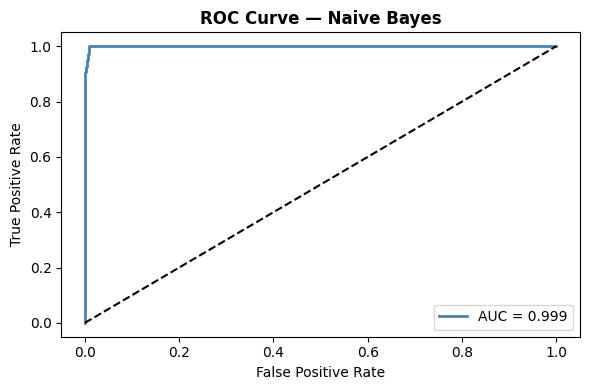

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('nb_roc_curve.png', dpi=150)
plt.show()

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)),
    ('nb', MultinomialNB(alpha=0.1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

print(f"CV F1 Scores : {cv_scores}")
print(f"Mean F1      : {cv_scores.mean():.4f}")
print(f"Std Dev      : {cv_scores.std():.4f}")

CV F1 Scores : [0.97426471 0.97597043 0.96435272 0.97407407 0.97217069]
Mean F1      : 0.9722
Std Dev      : 0.0041


In [ ]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'naive_bayes_model.pkl')
print("Saved: tfidf_vectorizer.pkl")
print("Saved: naive_bayes_model.pkl")

Saved: tfidf_vectorizer.pkl
Saved: naive_bayes_model.pkl
